# main.ipynb — Unified Pipeline

Integrates Prithvi-EO-2.0-300M and Prithvi-WxC end-to-end.

| Cell | Source | Description |
|------|--------|-------------|
| **0** | *(this repo)* | Setup & imports |
| **1** | `eo_data_installer.ipynb` | Authenticate & download EO dataset |
| **2** | `eo_extract_features.py` | Sliding window → encoder → save `mizuho_output/extracted_q_patch_*.pt` |
| **3** | `eo_attention_pooling.py` | Aggregate patches → Q `[1, 1024]` |
| **4** | `Prithvi-WxC/mycode.ipynb` Steps 1–5 | WxC pipeline → meteorological embedding `[B, N, 5120]` |
| **5** | `Prithvi-WxC/mycode.ipynb` Step 6 | Cross-Modal MHA: fuse Q (EO) × K,V (WxC) → `[B, N, 1024]` |
| **6** | `Prithvi-WxC/mycode.ipynb` Step 7 | MLP Regression Head → Yield Prediction ẑ `[B, N]` |
| **7** | *(this repo)* | Training loop (loss / optimizer / adapter) |

---
## Cell 0: Setup & Imports

In [ ]:
import sys, os
from pathlib import Path

# ════════════════════════════════════════════════════════════════════════════════
#  TARGET SETTINGS 
# ════════════════════════════════════════════════════════════════════════════════

# TARGET_GEOIDS = ["01001", "01003"]   # list of GEOID which wanna forcus
TARGET_GEOIDS = [
    # ── Major Agricultural Counties ──────────────────────────────────────────
    "06029",  # Kern, CA          (grapes, citrus, cotton)
    "06019",  # Fresno, CA        (almonds, grapes, tomatoes)
    "06077",  # San Joaquin, CA   (wine grapes, cherries)
    "06047",  # Merced, CA        (dairy, almonds)
    "06039",  # Madera, CA        (grapes, poultry)
    "06031",  # Kings, CA         (cotton, tomatoes)
    "06107",  # Tulare, CA        (dairy, citrus)
    "06099",  # Stanislaus, CA    (dairy, walnuts)
    "17019",  # Champaign, IL     (corn, soybeans)
    "17113",  # McLean, IL        (corn, soybeans)
    "17203",  # Woodford, IL      (corn, soybeans)
    "19153",  # Polk, IA          (corn, soybeans)
    "19013",  # Black Hawk, IA    (corn, hogs)
    "19193",  # Woodbury, IA      (corn, cattle)
    "20015",  # Butler, KS        (wheat, cattle)
    "20055",  # Finney, KS        (feedlots, wheat)
    "20057",  # Ford, KS          (beef cattle, wheat)
    "20091",  # Johnson, KS       (wheat, corn)
    "27013",  # Blue Earth, MN    (corn, soybeans)
    "27103",  # Nicollet, MN      (corn, soybeans)
    "28001",  # Adams, MS         (cotton, soybeans)
    "28027",  # Coahoma, MS       (cotton, rice)
    "28083",  # Leflore, MS       (cotton, soybeans)
    "29037",  # Cass, MO          (corn, soybeans)
    "31153",  # Sarpy, NE         (corn, soybeans)
    "31055",  # Douglas, NE       (corn, cattle)
    "31109",  # Lancaster, NE     (corn, soybeans)
    "35025",  # Lea, NM           (beef cattle, oil)
    "36067",  # Onondaga, NY      (dairy, apples)
    "37067",  # Forsyth, NC       (tobacco, sweet potatoes)
    "38015",  # Burleigh, ND      (wheat, sunflowers)
    "38017",  # Cass, ND          (wheat, soybeans)
    "39021",  # Champaign, OH     (corn, soybeans)
    "40109",  # Oklahoma, OK      (wheat, cattle)
    "41067",  # Washington, OR    (nursery, wheat)
    "42041",  # Cumberland, PA    (dairy, mushrooms)
    "45063",  # Lexington, SC     (peaches, poultry)
    "46099",  # Minnehaha, SD     (corn, soybeans)
    "47149",  # Rutherford, TN    (soybeans, tobacco)
    "48139",  # Ellis, TX         (cotton, wheat)
    "48269",  # King, TX          (beef cattle, cotton)
    "48381",  # Randall, TX       (feedlots, wheat)
    "48421",  # Sherman, TX       (wheat, feedlots)
    "48111",  # Dawson, TX        (cotton, sorghum)
    "49005",  # Cache, UT         (dairy, hay)
    "53077",  # Yakima, WA        (apples, hops)
    "53071",  # Walla Walla, WA   (wheat, wine grapes)
    "55025",  # Dane, WI          (dairy, corn)
    "55087",  # Polk, WI          (dairy, potatoes)
    "56021",  # Laramie, WY       (beef cattle, wheat)

    # ── Major Urban / Metro Counties ─────────────────────────────────────────
    "06037",  # Los Angeles, CA
    "06073",  # San Diego, CA
    "06075",  # San Francisco, CA
    "06085",  # Santa Clara, CA   (Silicon Valley)
    "08031",  # Denver, CO
    "09003",  # Hartford, CT
    "11001",  # Washington, DC
    "12086",  # Miami-Dade, FL
    "12057",  # Hillsborough, FL  (Tampa)
    "12095",  # Orange, FL        (Orlando)
    "13121",  # Fulton, GA        (Atlanta)
    "15003",  # Honolulu, HI
    "17031",  # Cook, IL          (Chicago)
    "18097",  # Marion, IN        (Indianapolis)
    "21111",  # Jefferson, KY     (Louisville)
    "22071",  # Orleans, LA       (New Orleans)
    "22033",  # East Baton Rouge, LA
    "25025",  # Suffolk, MA       (Boston)
    "24510",  # Baltimore City, MD
    "26163",  # Wayne, MI         (Detroit)
    "27053",  # Hennepin, MN      (Minneapolis)
    "28049",  # Hinds, MS         (Jackson)
    "29095",  # Jackson, MO       (Kansas City)
    "29189",  # St. Louis, MO
    "32003",  # Clark, NV         (Las Vegas)
    "33011",  # Hillsborough, NH  (Manchester)
    "34013",  # Essex, NJ         (Newark)
    "35001",  # Bernalillo, NM    (Albuquerque)
    "36005",  # Bronx, NY
    "36047",  # Kings, NY         (Brooklyn)
    "36061",  # New York, NY      (Manhattan)
    "36081",  # Queens, NY
    "37119",  # Mecklenburg, NC   (Charlotte)
    "39035",  # Cuyahoga, OH      (Cleveland)
    "39049",  # Franklin, OH      (Columbus)
    "39061",  # Hamilton, OH      (Cincinnati)
    "40143",  # Tulsa, OK
    "41051",  # Multnomah, OR     (Portland)
    "42101",  # Philadelphia, PA
    "44007",  # Providence, RI
    "45045",  # Greenville, SC
    "47037",  # Davidson, TN      (Nashville)
    "47157",  # Shelby, TN        (Memphis)
    "48029",  # Bexar, TX         (San Antonio)
    "48113",  # Dallas, TX
    "48201",  # Harris, TX        (Houston)
    "48453",  # Travis, TX        (Austin)
    "49035",  # Salt Lake, UT
    "51760",  # Richmond City, VA
    "51059",  # Fairfax, VA
    "53033",  # King, WA          (Seattle)
    "55079",  # Milwaukee, WI
]
TARGET_YEAR_EO   = 2020                  # year
# TARGET_CROP   = "CORN"                # "CORN" / "SOYBEANS" / "WHEAT" (etc.)

# ════════════════════════════════════════════════════════════════════════════════

# ── Submodule paths ────────────────────────────────────────────────────────────
REPO_ROOT   = Path("C:/Users/room208/mizuho")
EO_DIR      = REPO_ROOT / "Prithvi-EO-2.0-300M"
WXC_DIR     = REPO_ROOT / "Prithvi-WxC"
DATA_DIR    = REPO_ROOT / "data"
OUTPUT_DIR  = DATA_DIR   / "mizuho_output"


# ── Configuration ─────────────────────────────────────────────────────────────
YEAR_WxC         = 2020
MONTH        = 1    # January
INPUT_STEP   = 6    # hours between the two input snapshots
LEAD_TIME    = 12   # max forecast horizon in hours (covers both 6h and 12h forecasts)
MERRA_DIR     = DATA_DIR / "/merra-2"
RAW_DIR = DATA_DIR / "/raw"
CLIM_DIR     = DATA_DIR / "/climatology"
# ──────────────────────────────────────────────────────────────────────────────



for p in [EO_DIR, WXC_DIR]:
    assert p.exists(), f"Submodule not found: {p}"
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Common imports ─────────────────────────────────────────────────────────────
import gc
import yaml
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── getting information of target centroids based on TARGET_GEOIDS  ─────────────────────────────────
_df_gaz = pd.read_csv(
    DATA_DIR / "2025_Gaz_counties_national.txt",
    sep="|", dtype={"GEOID": str}
)
_df_gaz.columns = _df_gaz.columns.str.strip()
_df_gaz = _df_gaz[["GEOID", "NAME", "USPS", "INTPTLAT", "INTPTLONG"]].rename(
    columns={"INTPTLAT": "lat", "INTPTLONG": "lon", "USPS": "state"}
)

df_target = _df_gaz[_df_gaz["GEOID"].isin(TARGET_GEOIDS)].reset_index(drop=True)
assert len(df_target) > 0, f"GEOID not found: {TARGET_GEOIDS}"

RESOLVED_GEOIDS = df_target["GEOID"].tolist()

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    gc.collect()
    torch.cuda.empty_cache()
print(f"Device  : {device}")
print(f"Target Counties : {list(zip(RESOLVED_GEOIDS, df_target['NAME'].tolist()))}")
print("Submodule paths OK.")

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : NVIDIA GeForce RTX 4090
Device  : cuda
Target Counties : [('01001', 'Autauga County'), ('01003', 'Baldwin County')]
Submodule paths OK.


---
## Cell 1A: WxC Data Install
**Source:** `Prithvi-WxC\examples\Prithvi-WxC_input_data.ipynb, Prithvi-WxC\examples\PrithviWxC_inference.ipynb`  

In [ ]:
from time import sleep
from pathlib import Path

import numpy as np
from huggingface_hub import snapshot_download
from PrithviWxC.download import get_prithvi_wxc_input


# ── Step 1: Climatology (doy001–doy031 for January) ───────────────────────────
print("Downloading climatology files for January (doy001–doy031)...")
clim_patterns = [f"climatology/climate_surface_doy{d:03d}*.nc" for d in range(1, 32)]
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns=clim_patterns,
    local_dir= DATA_DIR
)
clim_patterns_vert = [f"climatology/climate_vertical_doy{d:03d}*.nc" for d in range(1, 32)]
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns=clim_patterns_vert,
    local_dir= DATA_DIR
)
surf_clim_dir = Path(CLIM_DIR)
vert_clim_dir = Path(CLIM_DIR)
print("Climatology download complete.\n")

# ── Step 2: MERRA-2 data (one day at a time) ──────────────────────────────────
start = np.datetime64(f"{YEAR_WxC:04d}-{MONTH:02d}-01")
end   = (
    np.datetime64(f"{YEAR_WxC:04d}-{MONTH+1:02d}-01")
    if MONTH < 12
    else np.datetime64(f"{YEAR_WxC+1:04d}-01-01")
)
days_in_month = int((end - start).astype(int))
dates = [start + np.timedelta64(d, 'D') for d in range(days_in_month)]

print(f"Downloading {len(dates)} days ({YEAR_WxC}-{MONTH:02d}) with lead_time={LEAD_TIME}h ...")

for date in dates:
    date_str = str(date)[:10]
    marker = Path(MERRA_DIR) / f".done_{date_str}"
    if marker.exists():
        print(f"  {date_str}: already on disk, skipping.")
        continue

    print(f"  {date_str}: downloading...", end=" ", flush=True)
    for tries in range(5):
        try:
            get_prithvi_wxc_input(
                date,
                input_time_step=INPUT_STEP,
                lead_time=LEAD_TIME,
                input_data_dir=MERRA_DIR,   # "./data/merra-2"  ← processed input data
                download_dir=RAW_DIR,       # "./data/raw"      ← raw downloaded files
            )
            marker.touch()
            print("done.")
            break
        except Exception as exc:
            print(f"\n    Attempt #{tries} failed: {exc.args[0]}")
            if tries < 4:
                wtime = 2 ** tries
                print(f"    Retrying in {wtime}s...", end=" ", flush=True)
                sleep(wtime)
            else:
                print(f"    Giving up on {date_str}. Re-run to retry.")

print("\nAll downloads complete.")

## Cell 1B: EO Data Install
**Source:** `eo_data_installer.ipynb`  
Authenticates via `_netrc` and downloads HLS satellite data for US counties.

In [ ]:
import earthaccess
import rasterio
import tempfile
from tqdm import tqdm

earthaccess.login(strategy="netrc")

# Prithvi-EO uses 6 HLS bands: Blue, Green, Red, NIR, SWIR1, SWIR2
HLS_BANDS = ["B02", "B03", "B04", "B05", "B06", "B07"]

def download_hls_for_counties(
    df_counties: pd.DataFrame,
    output_dir: str,
    temporal: tuple = ("2020-01-01", "2020-01-31"), # change to (f"{TARGET_YEAR}-01-01", f"{TARGET_YEAR}-12-31") for full year
    bbox_deg: float = 0.05,
    max_scenes_per_county: int = 1,
) -> dict:

    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    results_map = {}
    failed = []

    for _, row in tqdm(df_counties.iterrows(), total=len(df_counties)):
        geoid = row["GEOID"]
        lat   = float(row["lat"])
        lon   = float(row["lon"])

        # Skip if already downloaded
        existing = list(out_dir.glob(f"{geoid}_*.tif"))
        if existing:
            results_map[geoid] = str(existing[0])
            continue

        bbox = (lon - bbox_deg, lat - bbox_deg,
                lon + bbox_deg, lat + bbox_deg)

        try:
            # Try S30 first, then L30
            for concept_id in ["C2021957657-LPCLOUD", "C2021957295-LPCLOUD"]:
                granules = earthaccess.search_data(
                    concept_id=concept_id,
                    temporal=temporal,
                    bounding_box=bbox,
                    count=max_scenes_per_county,
                )
                if granules:
                    break

            if not granules:
                failed.append(geoid)
                continue

            granule   = granules[0]
            all_urls  = [f for f in granule.data_links()]
            band_urls = [u for u in all_urls if any(f".{b}.tif" in u for b in HLS_BANDS)]

            if len(band_urls) != 6:
                print(f"  [WARN] {geoid}: unexpected band count ({len(band_urls)})")
                failed.append(geoid)
                continue

            with tempfile.TemporaryDirectory() as tmp:
                files        = earthaccess.download(band_urls, local_path=tmp)
                files_sorted = sorted(files)  # B02 → B03 → ... order

                out_path = out_dir / f"{geoid}_HLS.tif"
                datasets = [rasterio.open(f) for f in files_sorted]
                profile  = datasets[0].profile.copy()
                profile.update(count=6)

                with rasterio.open(out_path, "w", **profile) as dst:
                    for i, ds in enumerate(datasets, start=1):
                        dst.write(ds.read(1), i)
                for ds in datasets:
                    ds.close()

            results_map[geoid] = str(out_path)

        except Exception as e:
            print(f"  [WARN] {geoid}: {e}")
            failed.append(geoid)

    print(f"\nDone: {len(results_map)}/{len(df_counties)} counties")
    print(f"Failed: {len(failed)} counties")
    return results_map


# --Run: Download HLS data for the target counties defined in Cell 0
print(f"Downloading HLS data for {len(RESOLVED_GEOIDS)} counties: {RESOLVED_GEOIDS}")

hls_results = download_hls_for_counties(
    df_target,
    output_dir=DATA_DIR / "hls_counties",
    temporal=(f"{TARGET_YEAR_EO}-01-01", f"{TARGET_YEAR_EO }-12-31"),
)

for geoid, path in hls_results.items():
    print(f"  {geoid}: {path}")

100%|██████████| 2/2 [00:00<00:00, 2673.23it/s]


Done: 2/2 counties
Failed: 0 counties
  01001: C:\Users\room208\mizuho\data\hls_counties\01001_HLS.tif
  01003: C:\Users\room208\mizuho\data\hls_counties\01003_HLS.tif


---
## Cell 2: EO Feature Extraction
**Source:** `eo_extract_features.py`  
Sliding window over GeoTIFF → Prithvi-EO encoder → saves `mizuho_output/extracted_q_patch_*.pt`

In [ ]:
import re
import datetime
import rasterio
import yaml
from typing import List, Union
from einops import rearrange
from prithvi_mae import PrithviMAE

NO_DATA       = -9999
NO_DATA_FLOAT = 0.0001

# ── Config ─────────────────────────────────────────────────────────────────────
EO_CONFIG_PATH     = EO_DIR / "config.json"
EO_CHECKPOINT_PATH = EO_DIR / "Prithvi_EO_V2_300M.pt"

# ── DATA_FILES: Auto-generated from Cell 1's hls_results ────────────────────────────────
# hls_results = {geoid: tif_path} — Already obtained from Cell 1
DATA_FILES = {
    geoid: path for geoid, path in hls_results.items()
    if Path(path).exists()
}
assert len(DATA_FILES) > 0, "DATA_FILES is empty. Please run Cell 1 first."
print(f"Target TIF files ({len(DATA_FILES)} files):")
for geoid, f in DATA_FILES.items():
    print(f"  {geoid}: {f}")

# ── Helper functions ───────────────────────────────────────────────────────────
def read_geotiff(file_path: str):
    with rasterio.open(file_path) as src:
        img   = src.read()
        meta  = src.meta
        try:
            coords = src.lnglat()
        except:
            coords = None
    return img, meta, coords

def load_example(file_paths, mean, std, indices=None):
    imgs, metas, temporal_coords, location_coords = [], [], [], []
    for file in file_paths:
        img, meta, coords = read_geotiff(file)
        img = np.moveaxis(img, 0, -1)
        if indices is not None:
            img = img[..., indices]
        img = np.where(img == NO_DATA, NO_DATA_FLOAT, (img - mean) / std)
        imgs.append(img)
        metas.append(meta)
        if coords is not None:
            location_coords.append(coords)
        try:
            match = re.search(r'(\d{7,8}T\d{6})', file)
            if match:
                year       = int(match.group(1)[:4])
                julian_day = match.group(1).split('T')[0][4:]
                julian_day = int(julian_day) if len(julian_day) == 3 else \
                             datetime.datetime.strptime(julian_day, '%m%d').timetuple().tm_yday
                temporal_coords.append([year, julian_day])
            else:
                # If HLS timestamp cannot be extracted, substitute with TARGET_YEAR
                temporal_coords.append([TARGET_YEAR_EO, 1])
        except Exception as e:
            temporal_coords.append([TARGET_YEAR_EO, 1])
    imgs = np.stack(imgs, axis=0)
    imgs = np.moveaxis(imgs, -1, 0).astype("float32")
    imgs = np.expand_dims(imgs, axis=0)
    return imgs, temporal_coords, location_coords, metas

def run_model_extract(model, input_data, temporal_coords, location_coords, device, save_path):
    model.eval()
    with torch.no_grad():
        x             = input_data.to(device)
        features_list = model.forward_features(x, temporal_coords, location_coords)
        q_embedding   = features_list[-1]
        torch.save(q_embedding.cpu(), save_path)
        print(f"--> Saved Q to {save_path}  shape: {q_embedding.shape}")

# ── Load config & model (once only) ────────────────────────────────────────────
import json as _json
with open(EO_CONFIG_PATH, "r") as f:
    eo_config = yaml.safe_load(f)['pretrained_cfg']

bands      = eo_config['bands']
mean       = eo_config['mean']
std        = eo_config['std']
img_size   = eo_config['img_size']
coords_enc = eo_config['coords_encoding']

eo_config_single = dict(eo_config)
eo_config_single.update(coords_encoding=coords_enc, num_frames=1, in_chans=len(bands))
eo_model = PrithviMAE(**eo_config_single)
eo_model.to(device)

state_dict = torch.load(EO_CHECKPOINT_PATH, map_location=device, weights_only=True)
for k in list(state_dict.keys()):
    if 'pos_embed' in k:
        del state_dict[k]
eo_model.load_state_dict(state_dict, strict=False)
print(f"Loaded EO checkpoint from {EO_CHECKPOINT_PATH}")

# ── Sliding window per county → patch extraction ─────────────────────────────
# Output: mizuho_output/{geoid}/extracted_q_patch_*.pt
patch_dirs = {}  # {geoid: output_dir_path}

for geoid, tif_path in DATA_FILES.items():
    print(f"\n── {geoid} ({tif_path}) ──")

    # Output directory per county
    geoid_out = OUTPUT_DIR / geoid
    geoid_out.mkdir(parents=True, exist_ok=True)
    patch_dirs[geoid] = geoid_out

    # 1 county = 1 file = 1 timestep
    input_data, temporal_coords, location_coords, meta_data = load_example(
        [tif_path], mean=mean, std=std
    )

    # Dynamically adjust coords_encoding
    _coords_enc = dict(coords_enc)
    if len(temporal_coords) == 0 and 'time' in _coords_enc:
        _coords_enc.pop('time')
    if not len(location_coords) and 'location' in _coords_enc:
        _coords_enc.pop('location')

    # Pad & sliding window
    original_h, original_w = input_data.shape[-2:]
    pad_h = img_size - (original_h % img_size) if original_h % img_size != 0 else 0
    pad_w = img_size - (original_w % img_size) if original_w % img_size != 0 else 0
    input_data = np.pad(
        input_data, ((0,0),(0,0),(0,0),(0,pad_h),(0,pad_w)), mode="reflect"
    )

    batch   = torch.tensor(input_data, device="cpu")
    windows = batch.unfold(3, img_size, img_size).unfold(4, img_size, img_size)
    windows = rearrange(
        windows, "b c t h1 w1 h w -> (b h1 w1) c t h w", h=img_size, w=img_size
    )
    windows = torch.tensor_split(windows, windows.shape[0], dim=0)

    temporal_coords_t = torch.Tensor(temporal_coords).unsqueeze(0).to(device)
    location_coords_t = torch.Tensor(location_coords[0]).unsqueeze(0).to(device) \
                        if location_coords else None

    for i, x in enumerate(windows):
        save_path = str(geoid_out / f"extracted_q_patch_{i}.pt")
        run_model_extract(eo_model, x, temporal_coords_t, location_coords_t, device, save_path)

    print(f"  → {len(windows)} patches saved to {geoid_out}")

print(f"\nFeature extraction complete. Target counties: {list(patch_dirs.keys())}")


Target TIF files (2 files):
  01001: C:\Users\room208\mizuho\data\hls_counties\01001_HLS.tif
  01003: C:\Users\room208\mizuho\data\hls_counties\01003_HLS.tif
Loaded EO checkpoint from C:\Users\room208\mizuho\Prithvi-EO-2.0-300M\Prithvi_EO_V2_300M.pt

── 01001 (C:\Users\room208\mizuho\data\hls_counties\01001_HLS.tif) ──
--> Saved Q to C:\Users\room208\mizuho\data\mizuho_output\01001\extracted_q_patch_0.pt  shape: torch.Size([1, 197, 1024])
--> Saved Q to C:\Users\room208\mizuho\data\mizuho_output\01001\extracted_q_patch_1.pt  shape: torch.Size([1, 197, 1024])
--> Saved Q to C:\Users\room208\mizuho\data\mizuho_output\01001\extracted_q_patch_2.pt  shape: torch.Size([1, 197, 1024])
--> Saved Q to C:\Users\room208\mizuho\data\mizuho_output\01001\extracted_q_patch_3.pt  shape: torch.Size([1, 197, 1024])
--> Saved Q to C:\Users\room208\mizuho\data\mizuho_output\01001\extracted_q_patch_4.pt  shape: torch.Size([1, 197, 1024])
--> Saved Q to C:\Users\room208\mizuho\data\mizuho_output\01001\extra

---
## Cell 3: EO Attention Pooling → Q
**Source:** `eo_attention_pooling.py`  
Aggregates variable-length patch sequence into a single fixed-length Q tensor `[1, 1024]`.

In [4]:
import glob

class PatchAttentionPooling(nn.Module):
    """
    Lightweight MLP attention over patch CLS tokens.
    Input : [B, N_patches, D]  →  Output: [B, D]
    """
    def __init__(self, embed_dim):
        super().__init__()
        self.attention_net = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.LayerNorm(embed_dim // 2),
            nn.Tanh(),
            nn.Linear(embed_dim // 2, 1),
        )

    def forward(self, patch_embeddings):
        attn_scores  = self.attention_net(patch_embeddings)        # [B, N, 1]
        attn_weights = F.softmax(attn_scores, dim=1)               # [B, N, 1]
        pooled       = torch.bmm(attn_weights.transpose(1, 2), patch_embeddings)  # [B, 1, D]
        return pooled.squeeze(1), attn_weights


def aggregate_patches_for_county(pt_dir, embed_dim=1024):
    """Performs Attention Pooling on patches for 1 county and returns Q [1, 1024]"""
    patch_files = sorted(
        glob.glob(str(Path(pt_dir) / "extracted_q_patch_*.pt")),
        key=lambda p: int(Path(p).stem.split("_")[-1])
    )
    if not patch_files:
        raise FileNotFoundError(f"Patch files not found: {pt_dir}")

    patch_vectors = []
    for f in patch_files:
        q_tensor  = torch.load(f)     # [1, N_tokens, D]
        cls_token = q_tensor[:, 0, :] # [1, D]
        patch_vectors.append(cls_token)

    county_patches = torch.stack(patch_vectors, dim=1)  # [1, N_patches, D]

    model = PatchAttentionPooling(embed_dim=embed_dim)
    model.eval()
    with torch.no_grad():
        county_embedding, weights = model(county_patches)

    return county_embedding  # [1, 1024]


# ── Attention Pooling per county → save Q ──────────────────────────────────────
# patch_dirs generated in Cell 2: {geoid: Path}
q_save_paths = {}  # {geoid: q_pt_path}

for geoid, pt_dir in patch_dirs.items():
    q = aggregate_patches_for_county(pt_dir)
    save_path = pt_dir / "final_county_embedding_q.pt"
    torch.save(q, save_path)
    q_save_paths[geoid] = save_path
    print(f"  {geoid}: Q shape = {q.shape}  → {save_path}")

print(f"\nAttention Pooling complete. Q saved for: {list(q_save_paths.keys())}")


  01001: Q shape = torch.Size([1, 1024])  → C:\Users\room208\mizuho\data\mizuho_output\01001\final_county_embedding_q.pt
  01003: Q shape = torch.Size([1, 1024])  → C:\Users\room208\mizuho\data\mizuho_output\01003\final_county_embedding_q.pt

Attention Pooling complete. Q saved for: ['01001', '01003']


In [ ]:
# Check statistics of final_q from Cell 3
final_q = torch.load(q_save_paths["01001"], map_location="cpu")
print(f"EO Q stats:")
print(f"  mean={final_q.mean():.4f}  std={final_q.std():.4f}  max={final_q.max():.4f}  min={final_q.min():.4f}")

EO Q stats:
  mean=0.0254  std=0.9081  max=26.6473  min=-3.6562


---
## Cell 4: WxC Weather Model Pipeline
**Source:** `Prithvi-WxC/mycode.ipynb` Steps 1–5  
Loads MERRA-2 data → Prithvi-WxC → global feature map → spatial query at county centroids → meteorological embedding `[B, N, 5120]`.

Next Step; more data
1day -> expand to 1 month
leadtime: Short-range forecast (6–12h)

In [6]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
from huggingface_hub import hf_hub_download
from PrithviWxC.model import PrithviWxC
from PrithviWxC.dataloaders.merra2 import (
    Merra2Dataset, preproc,
    input_scalers, output_scalers, static_input_scalers,
)

import gc
try:
    del eo_model
except NameError:
    pass
torch.cuda.empty_cache()
gc.collect()
print(f"GPU available: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

# trainable adapter layers (also used in Cell 7)
proj_clim  = torch.nn.Linear(160, 2560).to(device)
norm_wxc   = torch.nn.LayerNorm(2560).to(device)
norm_clim  = torch.nn.LayerNorm(2560).to(device)

print(f"proj_clim initialized: {160} → {2560}")
print(f"norm_wxc initialized: {2560}")
print(f"norm_clim initialized: {2560}")
# ── Config ─────────────────────────────────────────────────────────────────────
surface_vars        = ["EFLUX","GWETROOT","HFLUX","LAI","LWGAB","LWGEM","LWTUP",
                       "PS","QV2M","SLP","SWGNT","SWTNT","T2M","TQI","TQL","TQV",
                       "TS","U10M","V10M","Z0M"]
static_surface_vars = ["FRACI","FRLAND","FROCEAN","PHIS"]
vertical_vars       = ["CLOUD","H","OMEGA","PL","QI","QL","QV","T","U","V"]
levels              = [34,39,41,43,44,45,48,51,53,56,63,68,71,72]
padding             = {"level": [0,0], "lat": [0,-1], "lon": [0,0]}
lead_times          = [18]
input_times         = [-6]
positional_encoding = "fourier"

merra_dir = MERRA_DIR
clim_dir  = CLIM_DIR
# ── Step 1: Stacked input tensor ───────────────────────────────────────────────
def build_stacked_input(batch: dict) -> dict:
    Xt = batch["x"]
    S  = batch["static"]
    C  = batch.get("climate", None)
    assert C is not None, "climate key missing from batch"
    return {"Xt": Xt, "S": S, "C": C}

# ── Step 2: County centroids ───────────────────────────────────────────────────
def prepare_county_centroids(county_ids, lats, lons) -> dict:
    return {
        "county_ids": county_ids,
        "lats": torch.tensor(lats, dtype=torch.float32),
        "lons": torch.tensor(lons, dtype=torch.float32),
    }

def load_centroids_from_census_gazetteer(path: str) -> dict:
    df = pd.read_csv(path, sep="|", dtype={"GEOID": str}, encoding="utf-8-sig")
    df.columns = df.columns.str.strip()
    return prepare_county_centroids(
        df["GEOID"].tolist(),
        df["INTPTLAT"].tolist(),
        df["INTPTLONG"].tolist(),
    )

# ── Step 3: Global feature map via Prithvi-WxC (encoder only) ─────────────────
def get_global_feature_map(model, batch, device):
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.to(device)

    with torch.no_grad():
        model.eval()

        x_rescaled = (batch["x"] - model.input_scalers_mu) / (
            model.input_scalers_sigma + model.input_scalers_epsilon
        )
        x_rescaled = x_rescaled.flatten(1, 2)

        x_pos      = model.fourier_pos_encoding(batch["static"])
        x_static   = (batch["static"][:, 2:] - model.static_input_scalers_mu[:, 3:]) / (
            model.static_input_scalers_sigma[:, 3:] + model.static_input_scalers_epsilon
        )
        climate_scaled = (
            batch["climate"] - model.input_scalers_mu.view(1, -1, 1, 1)
        ) / (model.input_scalers_sigma.view(1, -1, 1, 1) + model.input_scalers_epsilon)

        x_emb      = model.patch_embedding(x_rescaled)
        static_emb = model.patch_embedding_static(
            torch.cat((x_static, climate_scaled), dim=1)
        )
        static_emb += x_pos
        x_emb      = model.to_patching(x_emb)
        static_emb = model.to_patching(static_emb)

        time_enc   = model.time_encoding(batch["input_time"], batch["lead_time"])
        tokens     = x_emb + static_emb + time_enc  # [B, G, L, D]

        # encoder のみ（decoderを通さない）
        x_encoded  = model.encoder(tokens)           # [B, G, L, D]

        print(f"x_encoded shape: {x_encoded.shape}")
        print(f"global_shape_mu: {model.global_shape_mu}")
        print(f"local_shape_mu:  {model.local_shape_mu}")
        print(f"embed_dim:       {model.embed_dim}")
        print(f"G0*G1 = {model.global_shape_mu[0]*model.global_shape_mu[1]}")
        print(f"L0*L1 = {model.local_shape_mu[0]*model.local_shape_mu[1]}")

        # [B, G, L, D] → [B, D, lat, lon]
        B          = x_encoded.shape[0]
        G0, G1     = model.global_shape_mu           # 45, 72
        L0, L1     = model.local_shape_mu            # 4, 4
        D          = model.embed_dim                 # 160

        x          = x_encoded.view(B, G0, G1, L0, L1, D)
        x          = x.permute(0, 5, 1, 3, 2, 4).contiguous()
        feature_map = x.view(B, D, G0 * L0, G1 * L1)  # [1, 160, 180, 288]

    return feature_map

# ── Step 4: Spatial query (bilinear interpolation at county centroids) ─────────
def spatial_query(feature_map, C, centroids, lat_grid, lon_grid):
    lats      = centroids["lats"]
    lons      = centroids["lons"]
    norm_lats = 2.0 * (lats - lat_grid.min()) / (lat_grid.max() - lat_grid.min()) - 1.0
    norm_lons = 2.0 * (lons - lon_grid.min()) / (lon_grid.max() - lon_grid.min()) - 1.0
    grid      = torch.stack([norm_lons, norm_lats], dim=-1)
    grid      = grid.unsqueeze(0).unsqueeze(0).expand(feature_map.shape[0], 1, -1, -1)
    county_weather_token     = F.grid_sample(
        feature_map, grid, mode="bilinear", align_corners=True
    ).squeeze(2).permute(0, 2, 1)
    local_climatology_vector = F.grid_sample(
        C, grid, mode="bilinear", align_corners=True
    ).squeeze(2).permute(0, 2, 1)
    return county_weather_token, local_climatology_vector

# ── Step 5: Meteorological embedding ──────────────────────────────────────────
def build_meteorological_embedding(county_weather_token, local_climatology_vector):
    return torch.cat([county_weather_token, local_climatology_vector], dim=-1)

# ── Load dataset & batch ───────────────────────────────────────────────────────
dataset = Merra2Dataset(
    time_range=("2020-01-01T00:00:00", "2020-01-02T05:59:59"),
    lead_times=lead_times,
    input_times=input_times,
    data_path_surface=merra_dir,
    data_path_vertical=merra_dir,
    climatology_path_surface=clim_dir,
    climatology_path_vertical=clim_dir,
    surface_vars=surface_vars,
    static_surface_vars=static_surface_vars,
    vertical_vars=vertical_vars,
    levels=levels,
    positional_encoding=positional_encoding,
)
assert len(dataset) > 0, "No valid data found"

data  = next(iter(dataset))
batch = preproc([data], padding)

# ── Scalers ────────────────────────────────────────────────────────────────────
in_mu,     in_sig    = input_scalers(surface_vars, vertical_vars, levels,
                           clim_dir/"musigma_surface.nc",
                           clim_dir/"musigma_vertical.nc")
output_sig            = output_scalers(surface_vars, vertical_vars, levels,
                           clim_dir/"anomaly_variance_surface.nc",
                           clim_dir/"anomaly_variance_vertical.nc")
static_mu, static_sig = static_input_scalers(clim_dir/"musigma_surface.nc",
                           static_surface_vars)

# ── Load WxC model ─────────────────────────────────────────────────────────────
with open(WXC_DIR / "data" / "config.yaml") as f:
    wxc_config = yaml.safe_load(f)
p = wxc_config["params"]

wxc_model = PrithviWxC(
    in_channels=p["in_channels"],
    input_size_time=p["input_size_time"],
    in_channels_static=p["in_channels_static"],
    input_scalers_mu=in_mu,
    input_scalers_sigma=in_sig,
    input_scalers_epsilon=p["input_scalers_epsilon"],
    static_input_scalers_mu=static_mu,
    static_input_scalers_sigma=static_sig,
    static_input_scalers_epsilon=p["static_input_scalers_epsilon"],
    output_scalers=output_sig**0.5,
    n_lats_px=p["n_lats_px"],
    n_lons_px=p["n_lons_px"],
    patch_size_px=p["patch_size_px"],
    mask_unit_size_px=p["mask_unit_size_px"],
    mask_ratio_inputs=0.0,
    mask_ratio_targets=0.0,
    embed_dim=p["embed_dim"],
    n_blocks_encoder=p["n_blocks_encoder"],
    n_blocks_decoder=p["n_blocks_decoder"],
    mlp_multiplier=p["mlp_multiplier"],
    n_heads=p["n_heads"],
    dropout=p["dropout"],
    drop_path=p["drop_path"],
    parameter_dropout=p["parameter_dropout"],
    residual="climate",
    masking_mode="global",
    encoder_shifting=True,
    decoder_shifting=True,
    positional_encoding=positional_encoding,
    checkpoint_encoder=[],
    checkpoint_decoder=[],
)

weights_path = WXC_DIR / "data" / "weights" / "prithvi.wxc.2300m.v1.pt"
state_dict   = torch.load(weights_path, weights_only=False)
state_dict   = state_dict.get("model_state", state_dict)
wxc_model.load_state_dict(state_dict, strict=True)
wxc_model    = wxc_model.to(device)

# ── Steps 3 → 5 ───────────────────────────────────────────────────────────────
feature_map = get_global_feature_map(wxc_model, batch, device)
print("feature_map shape:", feature_map.shape)   # [1, 160, 180, 288]
print(f"  mean={feature_map.mean():.4f}  std={feature_map.std():.4f}")

lat_grid = torch.linspace(-90,  90,  feature_map.shape[-2])
lon_grid = torch.linspace(-180, 180, feature_map.shape[-1])

# C_tensorも正規化
C_tensor = (batch["climate"].to(device) - wxc_model.input_scalers_mu.view(1, -1, 1, 1)) / (
    wxc_model.input_scalers_sigma.view(1, -1, 1, 1) + wxc_model.input_scalers_epsilon
)

centroids = {
    "county_ids": df_target["GEOID"].tolist(),
    "lats": torch.tensor(df_target["lat"].tolist(), dtype=torch.float32).to(device),
    "lons": torch.tensor(df_target["lon"].tolist(), dtype=torch.float32).to(device),
}
print(f"Number of target counties N = {len(centroids['county_ids'])}  {centroids['county_ids']}")

county_weather_token, local_climatology_vector = spatial_query(
    feature_map, C_tensor, centroids, lat_grid, lon_grid
)
print("county_weather_token shape:", county_weather_token.shape)
print(f"  mean={county_weather_token.mean():.4f}  std={county_weather_token.std():.4f}")

# Layer Normで両方をstd≈1に揃えてからconcat
wxc_normed      = norm_wxc(county_weather_token)
local_clim_proj = norm_clim(proj_clim(local_climatology_vector))

met_embedding = torch.cat([wxc_normed, local_clim_proj], dim=-1)  # [1, 2, 5120]

print("met_embedding shape:", met_embedding.shape)
print(f"mean={met_embedding.mean():.4f}  std={met_embedding.std():.4f}")

del wxc_model
torch.cuda.empty_cache()
gc.collect()

GPU空き: 22.7 GB
proj_clim initialized: 160 → 2560
norm_wxc initialized: 2560
norm_clim initialized: 2560


C:\Users\room208\AppData\Local\Programs\Python\Python313\Lib\contextlib.py:109: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


x_encoded shape: torch.Size([1, 216, 240, 2560])
global_shape_mu: (12, 18)
local_shape_mu:  (15, 16)
embed_dim:       2560
G0*G1 = 216
L0*L1 = 240
feature_map shape: torch.Size([1, 2560, 180, 288])
  mean=0.0009  std=3.2214
対象郡数 N = 2  ['01001', '01003']
county_weather_token shape: torch.Size([1, 2, 2560])
  mean=0.2510  std=3.0221
met_embedding shape: torch.Size([1, 2, 5120])
mean=0.0000  std=1.0000


7206

---
## Cell 5: Cross-Modal Multi-Head Attention → Fused Embedding
**Source:** `Prithvi-WxC/mycode.ipynb` Step 6  

| Role | Source | Shape |
|------|--------|-------|
| **Q** | Prithvi-EO (Cell 3) | `[B, N, 1024]` |
| **K = V** | Prithvi-WxC met embedding (Cell 4) | `[B, N, 5120]` |

K/V are projected from 5120 → 1024 before MHA. Residual + LayerNorm applied.

In [ ]:
class CrossModalAttention(nn.Module):
    """
    Q  = EO embedding      [B, N, D_eo=1024]
    K  = V = met_embedding [B, N, D_met=5120]
    Projects K,V → D_eo, runs MHA, applies residual + LayerNorm.
    Output: [B, N, D_eo]
    """
    def __init__(self, d_eo: int, d_met: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        self.kv_proj = nn.Linear(d_met, d_eo)
        self.attn    = nn.MultiheadAttention(
            embed_dim=d_eo, num_heads=n_heads,
            dropout=dropout, batch_first=True,
        )
        self.norm = nn.LayerNorm(d_eo)

    def forward(self, q: torch.Tensor, kv: torch.Tensor) -> torch.Tensor:
        kv_proj     = self.kv_proj(kv)
        attn_out, _ = self.attn(q, kv_proj, kv_proj)
        return self.norm(q + attn_out)  # [B, N, D_eo]


# ── Stack Q for all counties in RESOLVED_GEOIDS order to [1, N, 1024] ───────────────
eo_q_list = []
for geoid in RESOLVED_GEOIDS:
    q = torch.load(q_save_paths[geoid], map_location=device)  # [1, 1024]
    eo_q_list.append(q)

eo_q = torch.stack(eo_q_list, dim=1)  # [1, N, 1024]
print(f"EO Q (all counties) : {eo_q.shape}")

# ── Reorder met_embedding in RESOLVED_GEOIDS order ──────────────────────────
geoid_to_met_idx = {g: idx for idx, g in enumerate(centroids["county_ids"])}
met_indices = [geoid_to_met_idx[g] for g in RESOLVED_GEOIDS]
met_emb = met_embedding[:, met_indices, :]  # [1, N, 5120]
print(f"Met embedding       : {met_emb.shape}")

# ── Cross-Modal Attention (batch process all counties) ────────────────────────────────
D_eo    = eo_q.shape[-1]      # 1024
D_met   = met_emb.shape[-1]   # 2560+2560
n_heads = 8                   # 1024 % 8 == 0 ✓

cross_attn = CrossModalAttention(d_eo=D_eo, d_met=D_met, n_heads=n_heads).to(device)
fused = cross_attn(eo_q, met_emb)  # [1, N, 1024]

print("-" * 40)
print(f"Q  (EO)         : {eo_q.shape}")    # [1, N, 1024]
print(f"K=V (WxC)       : {met_emb.shape}") # [1, N, 5120]
print(f"Fused embedding : {fused.shape}")   # [1, N, 1024]


EO Q (all counties) : torch.Size([1, 2, 1024])
Met embedding       : torch.Size([1, 2, 5120])
----------------------------------------
Q  (EO)         : torch.Size([1, 2, 1024])
K=V (WxC)       : torch.Size([1, 2, 5120])
Fused embedding : torch.Size([1, 2, 1024])


In [9]:
print(f"feature_map shape: {feature_map.shape}")


feature_map shape: torch.Size([1, 2560, 180, 288])


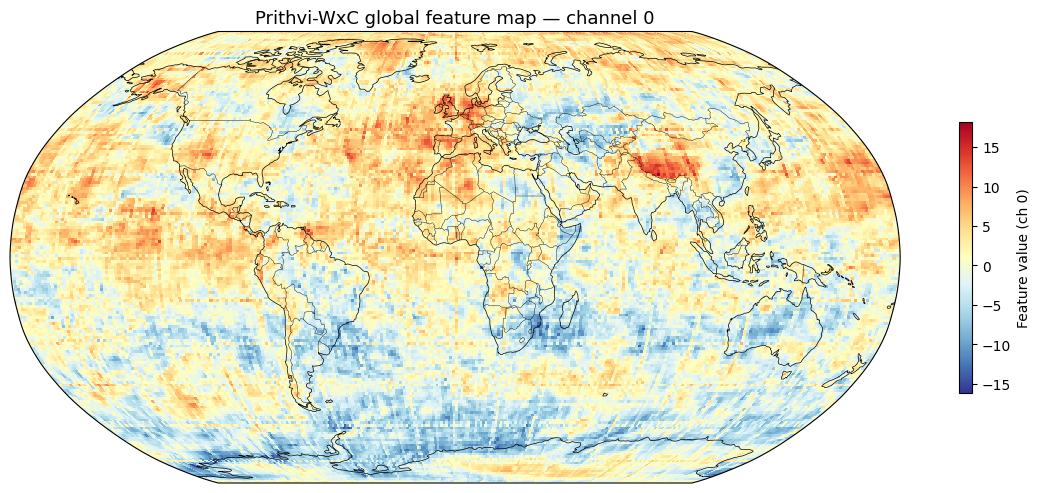

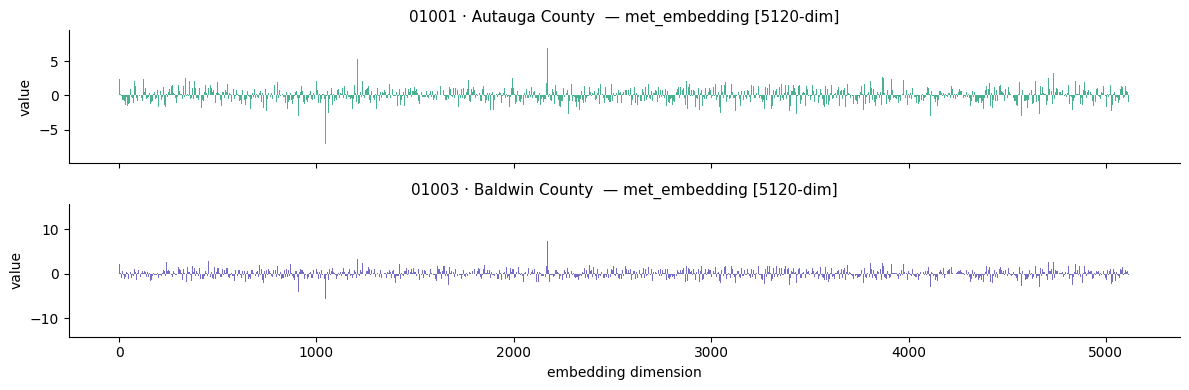

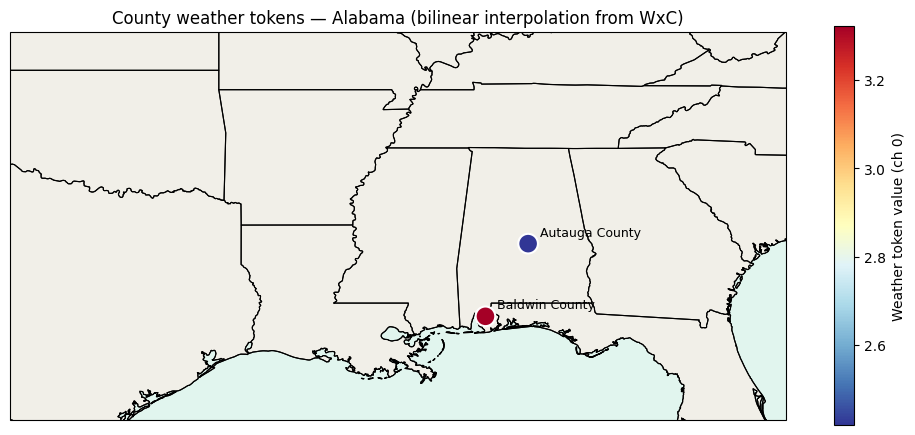

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch  # detach().cpu().numpy() を使用しているため
import pandas as pd  # df_target を使用しているため

# ═══════════════════════════════════════════════
# 1. feature_map — global weather feature map (Cell 4)
# ═══════════════════════════════════════════════
# channel 0 だけ可視化（160チャンネルの最初の1枚）
fm = feature_map[0, 0].detach().cpu().numpy()  # [360, 576]

fig, ax = plt.subplots(1, 1, figsize=(12, 5),
                       subplot_kw={"projection": ccrs.Robinson()})
ax.set_global()
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS,   linewidth=0.3)

lons = np.linspace(-180, 180, fm.shape[1])
lats = np.linspace(-90,   90, fm.shape[0])
im = ax.pcolormesh(lons, lats, fm,
                   transform=ccrs.PlateCarree(),
                   cmap="RdYlBu_r", shading="auto")
plt.colorbar(im, ax=ax, shrink=0.6, label="Feature value (ch 0)")
ax.set_title("Prithvi-WxC global feature map — channel 0", fontsize=13)
plt.tight_layout()
plt.show()



# ═══════════════════════════════════════════════
# 2. met_embedding — weather embedding for 2 counties (Cell 4-5)
# ═══════════════════════════════════════════════
met = met_embedding[0].detach().cpu().numpy()  # [2, 5120]
n_dim = met.shape[1]  # 自動で5120を取得

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
for i, (ax, geoid, name) in enumerate(zip(axes, RESOLVED_GEOIDS, df_target["NAME"].tolist())):
    ax.bar(range(n_dim), met[i], color=["#1D9E75","#534AB7"][i], width=1.0, alpha=0.8)
    ax.set_ylabel("value")
    ax.set_title(f"{geoid} · {name}  — met_embedding [{n_dim}-dim]", fontsize=11)
    ax.spines[["top","right"]].set_visible(False)
axes[-1].set_xlabel("embedding dimension")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════
# 3. county_weather_token — plot county locations on map
# ═══════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6),
                       subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-100, -80, 28, 38], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES,     linewidth=0.8)
ax.add_feature(cfeature.COASTLINE,  linewidth=0.8)
ax.add_feature(cfeature.LAND,       facecolor="#F1EFE8")
ax.add_feature(cfeature.OCEAN,      facecolor="#E1F5EE")

# plot county centroids
lats_c = df_target["lat"].tolist()
lons_c = df_target["lon"].tolist()
names  = df_target["NAME"].tolist()
tokens = county_weather_token[0].detach().cpu().numpy()  # [2, 160]
vals   = tokens[:, 0]  # channel 0 の値で色付け

sc = ax.scatter(lons_c, lats_c, c=vals, s=200,
                cmap="RdYlBu_r", transform=ccrs.PlateCarree(),
                edgecolors="white", linewidths=1.5, zorder=5)
plt.colorbar(sc, ax=ax, shrink=0.7, label="Weather token value (ch 0)")

for lon, lat, name in zip(lons_c, lats_c, names):
    ax.text(lon + 0.3, lat + 0.2, name, fontsize=9,
            transform=ccrs.PlateCarree())

ax.set_title("County weather tokens — Alabama (bilinear interpolation from WxC)", fontsize=12)
plt.tight_layout()
plt.show()


In [16]:
print("county_weather_token stats:")
print(f"  mean={county_weather_token.mean():.4f}  std={county_weather_token.std():.4f}  max={county_weather_token.max():.4f}")

print("local_climatology_vector stats:")
print(f"  mean={local_climatology_vector.mean():.4f}  std={local_climatology_vector.std():.4f}  max={local_climatology_vector.max():.4f}")

county_weather_token stats:
  mean=0.2510  std=3.0221  max=40.6204
local_climatology_vector stats:
  mean=0.1400  std=0.4967  max=2.6298


In [ ]:
# Cell 4実行後に追加して確認
print("=== Statistics of each embedding ===")
print(f"county_weather_token : mean={county_weather_token.mean():.4f}  std={county_weather_token.std():.4f}")
print(f"wxc_normed           : mean={wxc_normed.mean():.4f}  std={wxc_normed.std():.4f}")
print(f"local_clim_proj      : mean={local_clim_proj.mean():.4f}  std={local_clim_proj.std():.4f}")
print(f"met_embedding        : mean={met_embedding.mean():.4f}  std={met_embedding.std():.4f}")

=== 各埋め込みの統計 ===
county_weather_token : mean=0.2510  std=3.0221
wxc_normed           : mean=0.0000  std=1.0001
local_clim_proj      : mean=0.0000  std=1.0000
met_embedding        : mean=0.0000  std=1.0000


---
## Cell 6: MLP Regression Head → Yield Prediction ẑ
**Source:** `Prithvi-WxC/mycode.ipynb` Step 7  

Passes fused vector through MLP to output per-county yield prediction value ẑ.

```
[B, N, 1024] → Linear(1024→256) → GELU → Linear(256→128) → GELU → Linear(128→1) → [B, N]
```

In [12]:
class MLPRegressionHead(nn.Module):
    """
    Input : [B, N, D_eo=1024]
    Output: [B, N]  — per-county yield prediction ẑ
    """
    def __init__(self, d_in: int, hidden_dim: int = 256, dropout: float = 0.1):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_in, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(x).squeeze(-1)  # [B, N]


# ── Initialization ─────────────────────────────────────────────────────────────────────
mlp_head = MLPRegressionHead(d_in=D_eo).to(device)

# ── Inference (pre-training verification) ─────────────────────────────────────────────────
with torch.no_grad():
    y_hat = mlp_head(fused)  # [B, N]

print("-" * 40)
print("Fused input     :", fused.shape)   # [B, N, 1024]
print("Yield pred ẑ    :", y_hat.shape)   # [B, N]
print("Sample values   :", y_hat[0, :5])

----------------------------------------
Fused input     : torch.Size([1, 2, 1024])
Yield pred ẑ    : torch.Size([1, 2])
Sample values   : tensor([-0.0237, -0.0303], device='cuda:0')


# OUTPUT

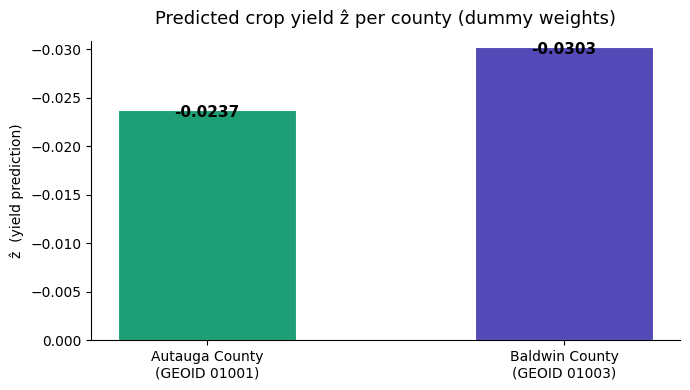

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ────────────────────────────────────────────────────────────────────
geoids = RESOLVED_GEOIDS                          # ['01001', '01003']
names  = df_target["NAME"].tolist()               # ['Autauga County', 'Baldwin County']
yields = y_hat[0].detach().cpu().numpy()          # [0.0403, 0.0437]

# ── Bar Chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

colors = ["#1D9E75", "#534AB7"]
bars   = ax.bar(names, yields, color=colors, width=0.5, edgecolor="white", linewidth=0.8)

# Display values above each bar
for bar, val in zip(bars, yields):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Predicted crop yield ẑ per county (dummy weights)", fontsize=13, pad=12)
ax.set_ylabel("ẑ  (yield prediction)")
ax.set_ylim(0, max(yields) * 1.3)
ax.spines[["top", "right"]].set_visible(False)

# Append GEOID to X-axis labels
ax.set_xticks(range(len(names)))
ax.set_xticklabels([f"{n}\n(GEOID {g})" for n, g in zip(names, geoids)], fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\room208\AppData\Local\Temp\ipykernel_19168\1937285607.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\Users\room208\mizuho\.venv\Lib\site-packages\cartopy\mpl\geoaxes.py:512: UserWarning: Glyph 37089 (\N{CJK UNIFIED IDEOGRAPH-90E1}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
c:\Users\room208\mizuho\.venv\Lib\site-packages\cartopy\mpl\geoaxes.py:512: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
c:\Users\room208\mizuho\.venv\Lib\site-packages\cartopy\mpl\geoaxes.py:512: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
c:\Users\room208\mizuho\.venv\Lib\site-packages\cartopy\mpl\geoaxes.py:512: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  

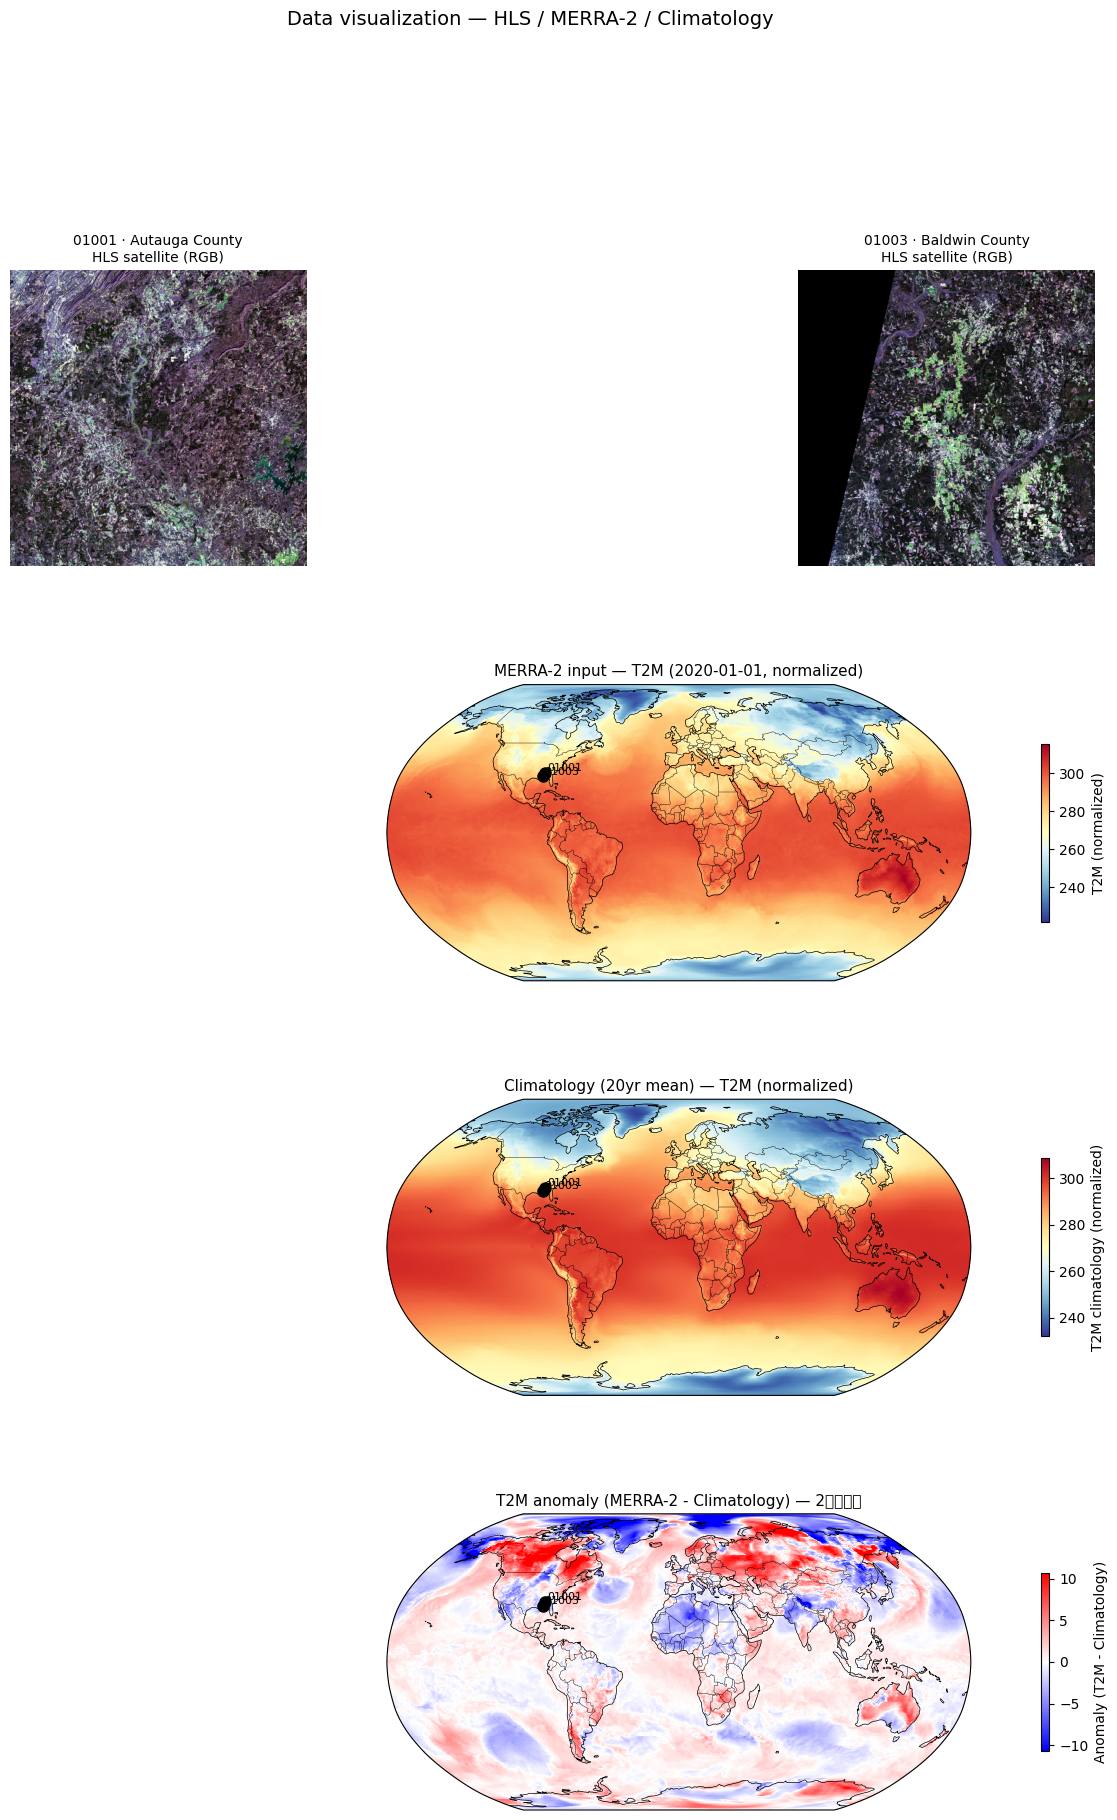

saved: data_visualization.png


In [ ]:
import rasterio
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.4, wspace=0.3)

# ═══════════════════════════════════════════════════════
# 1. HLS satellite imagery RGB (2 counties)
# ═══════════════════════════════════════════════════════
for col, (geoid, tif_path) in enumerate(DATA_FILES.items()):
    ax = fig.add_subplot(gs[0, col])
    with rasterio.open(tif_path) as src:
        r = src.read(3).astype(float)
        g = src.read(2).astype(float)
        b = src.read(1).astype(float)

    def norm(x):
        p2, p98 = np.percentile(x[x > 0], [2, 98]) if (x > 0).any() else (0, 1)
        return np.clip((x - p2) / (p98 - p2 + 1e-8), 0, 1)

    rgb = np.stack([norm(r), norm(g), norm(b)], axis=-1)
    name = df_target[df_target["GEOID"] == geoid]["NAME"].values[0]
    ax.imshow(rgb)
    ax.set_title(f"{geoid} · {name}\nHLS satellite (RGB)", fontsize=10)
    ax.axis("off")

# ═══════════════════════════════════════════════════════
# 2. MERRA-2 T2M (surface temperature) global map
# ═══════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[1, :], projection=ccrs.Robinson())
ax2.set_global()
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.add_feature(cfeature.BORDERS,   linewidth=0.3)

# T2Mのインデックスを取得
t2m_idx = surface_vars.index("T2M")
t2m = batch["x"][0, 0, t2m_idx].cpu().numpy()  # [lat, lon]

lons = np.linspace(-180, 180, t2m.shape[1])
lats = np.linspace(-90,   90, t2m.shape[0])
im2  = ax2.pcolormesh(lons, lats, t2m,
                      transform=ccrs.PlateCarree(),
                      cmap="RdYlBu_r", shading="auto")
plt.colorbar(im2, ax=ax2, shrink=0.6, label="T2M (normalized)")

# plot location of 2 counties
for geoid, row in df_target.set_index("GEOID").iterrows():
    ax2.plot(row["lon"], row["lat"], "o", ms=8, color="black",
             transform=ccrs.PlateCarree(), zorder=5)
    ax2.text(row["lon"]+1, row["lat"]+1, geoid,
             transform=ccrs.PlateCarree(), fontsize=8, color="black")

ax2.set_title("MERRA-2 input — T2M (2020-01-01, normalized)", fontsize=11)

# ═══════════════════════════════════════════════════════
# 3. Climatology T2M (20-year average) global map
# ═══════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[2, :], projection=ccrs.Robinson())
ax3.set_global()
ax3.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax3.add_feature(cfeature.BORDERS,   linewidth=0.3)

clim_t2m = batch["climate"][0, t2m_idx].cpu().numpy()  # [lat, lon]
im3 = ax3.pcolormesh(lons, lats, clim_t2m,
                     transform=ccrs.PlateCarree(),
                     cmap="RdYlBu_r", shading="auto")
plt.colorbar(im3, ax=ax3, shrink=0.6, label="T2M climatology (normalized)")

for geoid, row in df_target.set_index("GEOID").iterrows():
    ax3.plot(row["lon"], row["lat"], "o", ms=8, color="black",
             transform=ccrs.PlateCarree(), zorder=5)
    ax3.text(row["lon"]+1, row["lat"]+1, geoid,
             transform=ccrs.PlateCarree(), fontsize=8, color="black")

ax3.set_title("Climatology (20yr mean) — T2M (normalized)", fontsize=11)

# ═══════════════════════════════════════════════════════
# 4. MERRA-2 - Climatology difference (anomaly)
# ═══════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[3, :], projection=ccrs.Robinson())
ax4.set_global()
ax4.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax4.add_feature(cfeature.BORDERS,   linewidth=0.3)

anomaly = t2m - clim_t2m
vmax    = np.percentile(np.abs(anomaly), 98)
im4 = ax4.pcolormesh(lons, lats, anomaly,
                     transform=ccrs.PlateCarree(),
                     cmap="bwr", shading="auto",
                     vmin=-vmax, vmax=vmax)
plt.colorbar(im4, ax=ax4, shrink=0.6, label="Anomaly (T2M - Climatology)")

for geoid, row in df_target.set_index("GEOID").iterrows():
    ax4.plot(row["lon"], row["lat"], "o", ms=8, color="black",
             transform=ccrs.PlateCarree(), zorder=5)
    ax4.text(row["lon"]+1, row["lat"]+1, geoid,
             transform=ccrs.PlateCarree(), fontsize=8, color="black")

ax4.set_title("T2M anomaly (MERRA-2 - Climatology) — Location of 2 counties", fontsize=11)

plt.suptitle("Data visualization — HLS / MERRA-2 / Climatology", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("data_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved: data_visualization.png")